I dette prosjektet har vi valgt å skrive norsk i svarene på oppgave og kommentarene til plottene, men engelsk i all kode og kommentarer i kode.

# Oppgave 1a)

$$
 \partial_x^2y(x) = -4\sin(2x) \hspace{10px} ,  \hspace{10px}y(0)=0\hspace{10px} ,  \hspace{10px}\partial_x y(0)=2
$$

$$
\partial_x y(x) = \int\partial_x^2y(x) dx = 2\cos(2x) + A
$$

$$
y(x) = \int\partial_xy(x) dx = \sin(2x) + Ax + B
$$

$$
\partial_x y(0) = 2 \Longrightarrow 2+A = 2 \Longrightarrow A=0
$$

$$
\Longrightarrow y(x) = \int\partial_xy(x) dx = \sin(2x) + B
$$

$$
y(0)=0 \Longrightarrow B=0
$$

$$
\Longrightarrow y(x) = \sin(2x)\hspace{10px} \square
$$

# Oppgave 1b)
$$
\vec{y} (x) = \begin{pmatrix} y(x) \\ \partial_x y(x) \end{pmatrix}
$$

$$
\partial_x \vec{y} (x) = \begin{pmatrix} \partial_xy(x) \\ -4\sin(2x) \end{pmatrix}
$$

$$
\vec{y} (0) = \begin{pmatrix} 0 \\ 2 \end{pmatrix}
$$

# Oppgave 1c)

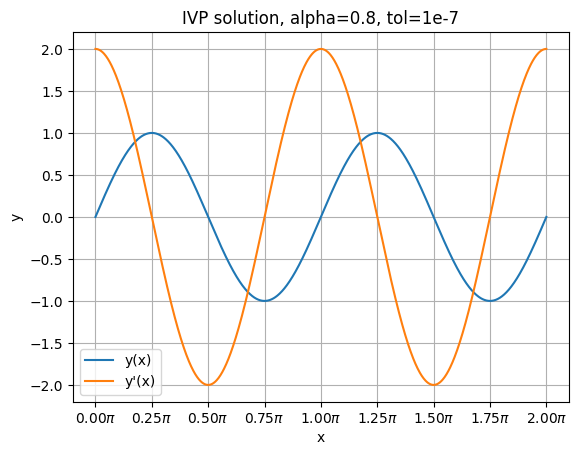

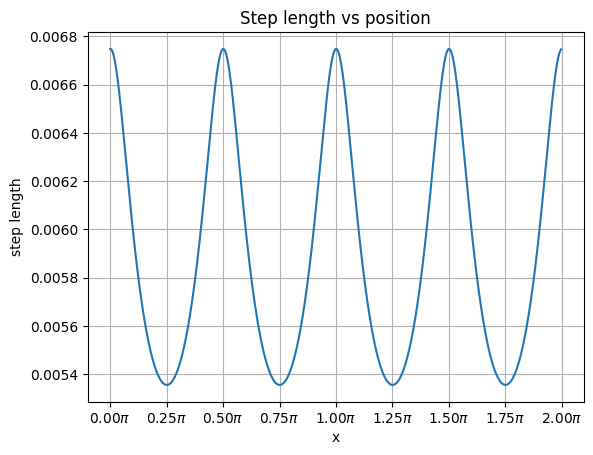

In [4]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np


def f(x: float, y: np.ndarray) -> np.ndarray:
    return np.array([y[1], -4 * np.sin(2 * x)])


def solve_ivp(
    x_init: float,
    x_end: float,
    y_init: np.ndarray,
    h_0: float,
    tol: float,
    f: Callable,
    alpha: float,
) -> tuple[list[float], list[np.ndarray], int]:
    h = h_0
    n = 0
    x = [x_init]
    y = [y_init]
    k_1 = f(x_init, y_init)
    num_steps = 0
    while x[n] < x_end:
        num_steps += 1
        h = min(h, x_end - x[n])
        k_2 = f(x[n] + 1 / 2 * h, y[n] + 1 / 2 * h * k_1)
        k_3 = f(x[n] + 3 / 4 * h, y[n] + 3 / 4 * h * k_2)
        y_new = y[n] + 1 / 9 * h * (2 * k_1 + 3 * k_2 + 4 * k_3)
        x_new = x[n] + h
        k_4 = f(x_new, y_new)
        z = y[n] + 1 / 24 * h * (7 * k_1 + 6 * k_2 + 8 * k_3 + 3 * k_4)
        est = np.linalg.norm(y_new - z)
        if est < tol:
            n += 1
            k_1 = k_4
            x.append(x_new)
            y.append(y_new)
        h = float(alpha * h * (tol / est) ** (1 / 3))

    return x, y, num_steps


X_START = 0
X_END = 2 * np.pi
Y_INIT = np.array((0, 2))
H0 = 0.01
TOL = 1e-7
ALPHA = 0.8

x_list, y_list, _ = solve_ivp(X_START, X_END, Y_INIT, H0, TOL, f, ALPHA)

x_ticks_2_pi = np.linspace(0, 2 * np.pi, 9)
x_ticks_2_pi_labels = [rf"{x:.2f}$\pi$" for x in np.linspace(0, 2, 9)]

# Plot the results
plt.plot(x_list, [y[0] for y in y_list], label="y(x)")
plt.plot(x_list, [y[1] for y in y_list], label="y'(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("IVP solution, alpha=0.8, tol=1e-7")
plt.grid()
plt.xticks(x_ticks_2_pi, x_ticks_2_pi_labels)
plt.show()


# Exclude last step length as it depends only on the x_end paramater, not the variable step.
plt.plot(x_list[:-2], np.diff(x_list)[:-1])
plt.xlabel("x")
plt.ylabel("step length")
plt.title("Step length vs position")
plt.xticks(x_ticks_2_pi, x_ticks_2_pi_labels)
plt.grid()
plt.show()

### Plot 1:
 - Her ser vi løsningen av initialverdiproblemet og dens deriverte. 
 - Vi ser at den stemmer godt overens med den analytiske løsningen.

### Plot 2:
 - Vi ser at steglengden varierer periodisk med posisjonen.

### Svar på oppgave:
Vi ser at steglengden konsekvent er lavest der absoluttverdien til den dobbeltderiverte er størst. Altså der funksjonen sin deriverte endrer seg raskest. Dette forklares ved at RK approksimerer funksjonen med førsteordens deriverte, og dermed ikke fungerer like bra hvis funksjonen har stor dobbeltderivert.


# Oppgave 1d)


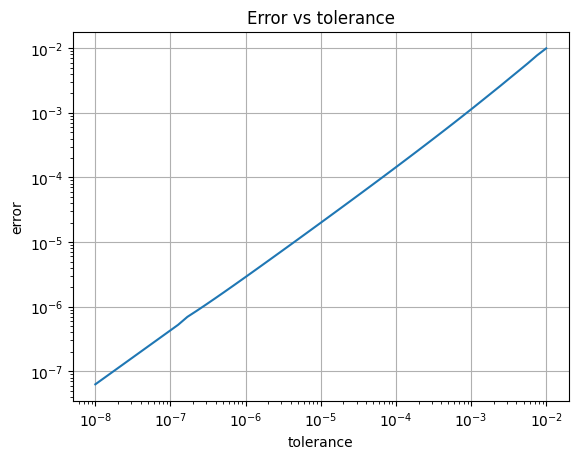

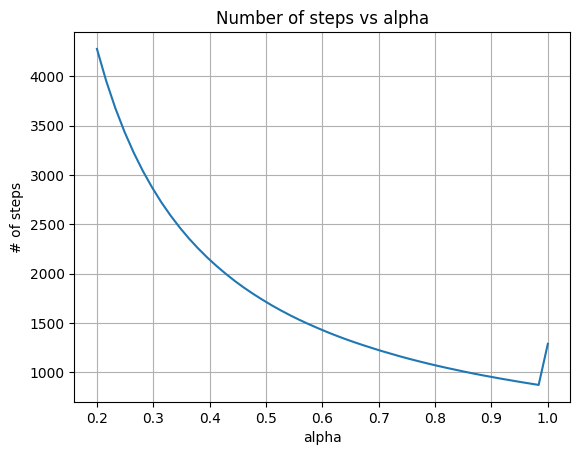

In [5]:
def y_anal(x: np.ndarray) -> np.ndarray:
    return np.array([np.sin(2 * x), 2 * np.cos(2 * x)]).T


tols = np.logspace(-8, -2, 50)
errors = []
for tol in tols:
    x_list, y_list, _ = solve_ivp(X_START, X_END, Y_INIT, H0, tol, f, ALPHA)
    x_arr, y_arr = np.array(x_list), np.array(y_list)
    y_arr_anal = y_anal(x_arr)
    error = np.linalg.norm(y_arr_anal - y_arr)
    errors.append(error)

alphas = np.linspace(0.2, 1, 50)
num_steps_list = []
for alpha in alphas:
    _, _, num_steps = solve_ivp(X_START, X_END, Y_INIT, H0, TOL, f, alpha)
    num_steps_list.append(num_steps)


plt.plot(tols, errors)
plt.xlabel("tolerance")
plt.ylabel("error")
plt.xscale("log")
plt.yscale("log")
plt.title("Error vs tolerance")
plt.grid()
plt.show()

plt.plot(alphas, num_steps_list)
plt.xlabel("alpha")
plt.ylabel("# of steps")
plt.title("Number of steps vs alpha")
plt.grid()
plt.show()

### Plot 1:
 - Vi ser en lineær relasjon mellom feilen i løseren og toleransen. 
 - Vi ser at feilen synker med synkende toleranse.
 - Dette gir mye mening ettersom toleransen skal være en øvre grense på feilen vi tillater.

### Plot 2:
 - Vi ser at antall steg i løseren synker med økende alpha.
 - Ettersom alpha er en pessimist-faktor kan man se på den som en direkte justering av antall steg, siden den justerer på steglengden i hvert steg. En mindre alpha vil bety at man i hvert steg tar et mindre steg enn nødvendig, noe som fører til flere steg totalt.


# Oppgave 1e

In [6]:
def root_finder(z_0: float, z_1: float, g: Callable, tol: float) -> float:
    z_neg_1 = z_1
    z_neg_2 = z_0
    iters = 0
    while abs(z_neg_1 - z_neg_2) > tol:
        iters += 1
        num = z_neg_2 * g(z_neg_1) - z_neg_1 * g(z_neg_2)
        den = g(z_neg_1) - g(z_neg_2)
        z_neg_1, z_neg_2 = num / den, z_neg_1
    print(f"Number of iterations for root_finder: {iters}")
    return z_neg_1


def test_g(z: float) -> float:
    return z + np.sin(z) + np.cos(z)


root = root_finder(0, 0.1, test_g, TOL)
print(root)

Number of iterations for root_finder: 5
-0.4566247045676011


Nullpunktet ble også funnet i geogebra for å bekrefte at rett nullpunkt ble funnet.

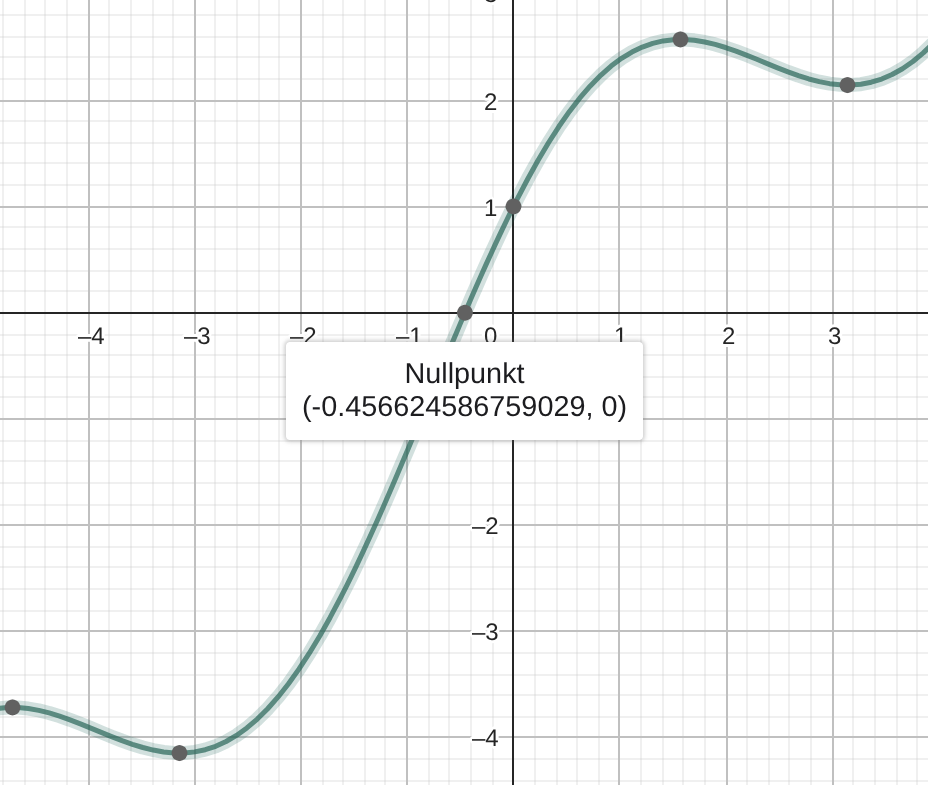

# Oppgave 1f

Number of iterations for root_finder: 2


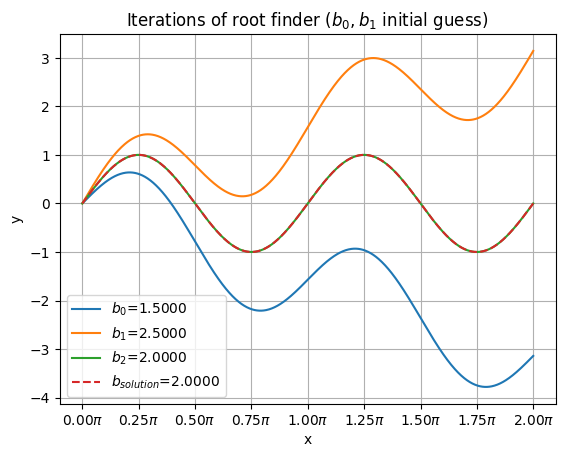

In [7]:
# Simple cache system used to save the values from the root_finder to later plot them.
y_b_cache = {}


def y_b(b: float) -> float:
    if b not in y_b_cache:
        y_init = np.array([0, b])
        y_b_cache[b] = solve_ivp(X_START, X_END, y_init, H0, TOL, f, ALPHA)
    _, y_list, _ = y_b_cache[b]
    return y_list[-1][0]


root = root_finder(2.5, 1.5, y_b, TOL)

for idx, b in enumerate(y_b_cache):
    x_list, y_list, _ = y_b_cache[b]
    plt.plot(x_list, [y[0] for y in y_list], label=f"$b_{idx}$={b:.4f}")

y_init = np.array([0, root])
x_list, y_list, _ = solve_ivp(X_START, X_END, y_init, H0, TOL, f, ALPHA)
plt.plot(
    x_list,
    [y[0] for y in y_list],
    label=r"$b_{solution}$" + f"={root:.4f}",
    linestyle="--",
)


plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title(r"Iterations of root finder ($b_0, b_1$ initial guess)")
plt.xticks(x_ticks_2_pi, x_ticks_2_pi_labels)
plt.grid()
plt.show()

 - Vi tippet løsningene $b_0=1.5$ og $b_1=2.5$, som vi ser var ikke disse rett løsning.
 - Etter én iterasjon med sekantmetoden nådde vi allerede en b som var tilnærmet lik den faktiske løsningen på randverdiproblemet. 
 - Dette hadde fungert for hvilke som helst initielle gjett av $b_0$ og $b_1$, så lenge de ikke er like. Akkurat de to verdiene som ble brukt ble valgt for å gjøre plottet fint :)

# Oppgave 1g/h

Number of iterations for root_finder: 2
root_solver time: 0.324 s, solve_bvp time: 0.026 s


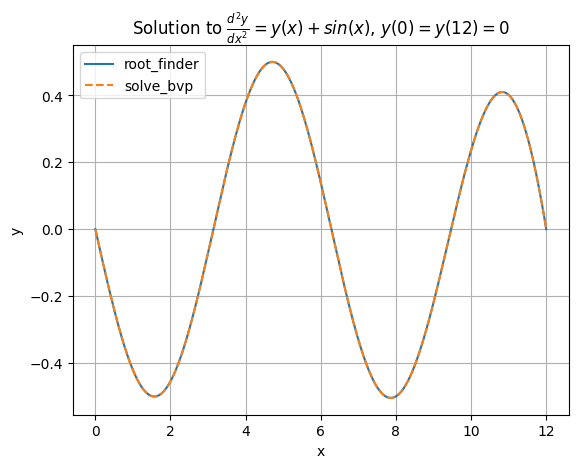

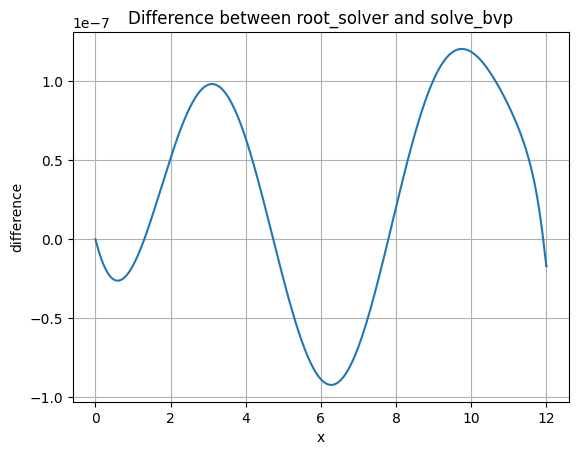

In [8]:
import time

from scipy.integrate import solve_bvp


def f_oppg_1g(x: float, y: np.ndarray) -> np.ndarray:
    return np.array([y[1], y[0] + np.sin(x)])


def boundary_oppg_1g(left, right):
    return np.array((left[0], right[0]))


y_b_cache = {}


def y_b_oppg_1g(b: float) -> float:
    if b not in y_b_cache:
        y_init = np.array([0, b])
        y_b_cache[b] = solve_ivp(X_START, 12, y_init, H0, TOL, f_oppg_1g, ALPHA)
    _, y_list, _ = y_b_cache[b]
    return y_list[-1][0]


# Measure time taken for root_finder method.
start_time = time.perf_counter()
root = root_finder(1, 2, y_b_oppg_1g, TOL)
root_solver_time = time.perf_counter() - start_time

y_init = np.array([0, root])
x_list, y_list, _ = solve_ivp(X_START, 12, y_init, H0, TOL, f_oppg_1g, ALPHA)


# Measure time taken for solve_bvp method.
start_time = time.perf_counter()
sol = solve_bvp(f_oppg_1g, boundary_oppg_1g, x_list, np.zeros(shape=(2, len(x_list))))
solve_bvp_time = time.perf_counter() - start_time

print(
    f"root_solver time: {root_solver_time:.3f} s, solve_bvp time: {solve_bvp_time:.3f} s"
)

plt.plot(x_list, [y[0] for y in y_list], label="root_finder")
plt.plot(x_list, sol.sol(x_list)[0], "--", label="solve_bvp")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title(r"Solution to $\frac{d^2y}{dx^2}=y(x)+sin(x)$, $y(0)=y(12)=0$")
plt.grid()
plt.show()

plt.plot(x_list, sol.sol(x_list)[0] - np.array([y[0] for y in y_list]))
plt.xlabel("x")
plt.ylabel("difference")
plt.title("Difference between root_solver and solve_bvp")
plt.grid()
plt.show()

### Tid
 - solve_bvp fra scipy er rundt to størrelsesordner raskere enn metoden vi implementerte.
 - Vi skjønner derfor veldig godt hvorfor vi skal bruke den fra scipy videre.

### Plot 1
 - Vi ser at løsningene til BVPen fra begge metodene er tilnermet like. Som vi forventet så ga differensiallikningen en periodisk løsning.

### Plot 2
 - Vi ser at forskjellen mellom de to løsningene er svært lite, på skalaen $10^{-7}$, noe som samsvarer med toleransen begge metodene fikk, som var på nøyaktig $10^{-7}$.
 - Forskjellen mellom de to oscillerer med en samsvarende periode som løsningen selv.

# Oppgave 2a/b

In [ ]:
from typing import Any

from numba import njit

complex_array = np.ndarray[Any, np.dtype[np.complexfloating]]

M_SHAPE = (2, 2)
M_SHAPE_SINGLE = 2
M_VEC_SHAPE = 8
V_VEC_SHAPE = 32


@njit
def complex_ravel(m: complex_array) -> np.ndarray:
    """Ravel a 2x2 complex matrix into a an 8-length vector. Real values first."""

    out = np.empty(m.shape[:-2] + (8,), dtype=np.float64)


    out[..., 0] = m[..., 0, 0].real
    out[:, 0] = m[:, 0, 0].real


    out[..., 1] = m[..., 0, 1].real
    out[..., 2] = m[..., 1, 0].real
    out[..., 3] = m[..., 1, 1].real
    out[..., 4] = m[..., 0, 0].imag
    out[..., 5] = m[..., 0, 1].imag
    out[..., 6] = m[..., 1, 0].imag
    out[..., 7] = m[..., 1, 1].imag
    return out


@njit
def complex_unravel(m: np.ndarray) -> complex_array:
    """Unravel an 8-length vector into a 2x2 complex matrix. Real values first."""

    out = np.empty(m.shape[:-1] + (2, 2), dtype=np.complex128)

    out[..., 0, 0] = m[..., 0] + m[..., 4] * 1j
    out[..., 0, 1] = m[..., 1] + m[..., 5] * 1j
    out[..., 1, 0] = m[..., 2] + m[..., 6] * 1j
    out[..., 1, 1] = m[..., 3] + m[..., 7] * 1j

    return out


@njit
def concatenate_m(
    m_1: np.ndarray, m_2: np.ndarray, m_3: np.ndarray, m_4: np.ndarray
) -> np.ndarray:
    """Concatenate 4 8-length vectors into one 32-length vector."""

    out = np.empty(m_1.shape[:-1] + (V_VEC_SHAPE,), dtype=np.float64)

    QUARTER_LENGTH = 8
    out[..., :QUARTER_LENGTH] = m_1
    out[..., QUARTER_LENGTH : 2 * QUARTER_LENGTH] = m_2
    out[..., 2 * QUARTER_LENGTH : 3 * QUARTER_LENGTH] = m_3
    out[..., 3 * QUARTER_LENGTH :] = m_4

    return out


@njit
def unconcatenate_v(
    v: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Unconcatenate one 32-length vector into 4 8-length vectors."""

    QUARTER_LENGTH = 8
    m_1 = v[..., :QUARTER_LENGTH]
    m_2 = v[..., QUARTER_LENGTH : 2 * QUARTER_LENGTH]
    m_3 = v[..., 2 * QUARTER_LENGTH : 3 * QUARTER_LENGTH]
    m_4 = v[..., 3 * QUARTER_LENGTH :]

    return m_1, m_2, m_3, m_4


print("### Task 2a: Ravel/Unravel")

m = np.array([[[1 + 1j, 2 + 2j], [3 + 3j, 4 + 4j]]])
print("Original matrix:")
print(m)

m_ravel = complex_ravel(m)
print("\nRaveled matrix:")
print(m_ravel)

m_unravel = complex_unravel(m_ravel)
print("\nUnraveled matrix:")
print(m_unravel)

print("\nAll elements equal:", (m_unravel == m).all())


print("\n\n### Task 2b: Concat/Unconcat")

m_1 = complex_ravel(np.array([[[1 + 1j, 2 + 2j], [3 + 3j, 4 + 4j]]]))
m_2 = complex_ravel(np.array([[[2 + 2j, 3 + 3j], [4 + 4j, 5 + 5j]]]))
m_3 = complex_ravel(np.array([[[3 + 3j, 4 + 4j], [5 + 5j, 6 + 6j]]]))
m_4 = complex_ravel(np.array([[[4 + 4j, 5 + 5j], [6 + 6j, 7 + 7j]]]))
print("Original matrixes:")
print(m_1, m_2, m_3, m_4)

v = concatenate_m(m_1, m_2, m_3, m_4)
print("\nConcatenated vec:")
print(v)

m_unconcats = unconcatenate_v(v)
print("\nUnconcatenated matrixes:")
print(*m_unconcats)

print(
    "\nAll elements equal:",
    np.array(
        [
            m_1 == m_unconcats[0],
            m_2 == m_unconcats[1],
            m_3 == m_unconcats[2],
            m_4 == m_unconcats[3],
        ]
    ).all(),
)


### Task 2a: Ravel/Unravel
Original matrix:
[[[1.+1.j 2.+2.j]
  [3.+3.j 4.+4.j]]]

Raveled matrix:
[[1. 2. 3. 4. 1. 2. 3. 4.]]

Unraveled matrix:
[[[1.+1.j 2.+2.j]
  [3.+3.j 4.+4.j]]]

All elements equal: True


### Task 2b: Concat/Unconcat
Original matrixes:
[[1. 2. 3. 4. 1. 2. 3. 4.]] [[2. 3. 4. 5. 2. 3. 4. 5.]] [[3. 4. 5. 6. 3. 4. 5. 6.]] [[4. 5. 6. 7. 4. 5. 6. 7.]]

Concatenated vec:
[[1. 2. 3. 4. 1. 2. 3. 4. 2. 3. 4. 5. 2. 3. 4. 5. 3. 4. 5. 6. 3. 4. 5. 6.
  4. 5. 6. 7. 4. 5. 6. 7.]]

Unconcatenated matrixes:
[[1. 2. 3. 4. 1. 2. 3. 4.]] [[2. 3. 4. 5. 2. 3. 4. 5.]] [[3. 4. 5. 6. 3. 4. 5. 6.]] [[4. 5. 6. 7. 4. 5. 6. 7.]]

All elements equal: True


Vi sjekket at funksjonene var korrekt ved å bruke funksjonen på en matrise, deretter bruke den inverse funksjonen og sjekke om alle elementene i matrisen var like som før, noe de var. Vi valgte å både vektorisere og bruke JIT for å optimalisere med tanke på kjøretid i videre oppgaver.

# Oppgave 2c

In [10]:
@njit
def matrices_to_vec(
    gamma: np.ndarray,
    gamma_tilde: np.ndarray,
    omega: np.ndarray,
    omega_tilde: np.ndarray,
) -> np.ndarray:
    return concatenate_m(
        complex_ravel(gamma),
        complex_ravel(gamma_tilde),
        complex_ravel(omega),
        complex_ravel(omega_tilde),
    )

@njit
def vec_to_matrices(
    v: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    v_1, v_2, v_3, v_4 = unconcatenate_v(v)
    gamma = complex_unravel(v_1)
    gamma_tilde = complex_unravel(v_2)
    omega = complex_unravel(v_3)
    omega_tilde = complex_unravel(v_4)
    return gamma, gamma_tilde, omega, omega_tilde


Måten vi transformerer fra ricatti-matrisene til vektoren v er ved å først skrive om alle matrisene til vektorer med åtte elementer med funksjonene fra oppgave 2a, og deretter sette de sammen til en enkelt vektor med funksjonen fra oppgave 2b. Transformasjonen fra vektor v til ricatti-matriser er den samme bare at vi bruker de inverse funksjonene i stedet.

$$

\vec{v} = \begin{pmatrix} 
Re(\gamma)_{00} \\
Re(\gamma)_{01} \\
Re(\gamma)_{10} \\
Re(\gamma)_{11} \\
Im(\gamma)_{00} \\
Im(\gamma)_{01} \\
Im(\gamma)_{10} \\
Im(\gamma)_{11} \\

Re(\tilde{\gamma})_{00} \\
Re(\tilde{\gamma})_{01} \\
Re(\tilde{\gamma})_{10} \\
Re(\tilde{\gamma})_{11} \\
Im(\tilde{\gamma})_{00} \\
Im(\tilde{\gamma})_{01} \\
Im(\tilde{\gamma})_{10} \\
Im(\tilde{\gamma})_{11} \\

Re(\omega)_{00} \\
Re(\omega)_{01} \\
Re(\omega)_{10} \\
Re(\omega)_{11} \\
Im(\omega)_{00} \\
Im(\omega)_{01} \\
Im(\omega)_{10} \\
Im(\omega)_{11} \\

Re(\tilde{\omega})_{00} \\
Re(\tilde{\omega})_{01} \\
Re(\tilde{\omega})_{10} \\
Re(\tilde{\omega})_{11} \\
Im(\tilde{\omega})_{00} \\
Im(\tilde{\omega})_{01} \\
Im(\tilde{\omega})_{10} \\
Im(\tilde{\omega})_{11} \\
\end{pmatrix}
$$

# Oppgave 2d

In [11]:
DELTA = 0.01
IDENTITY_2X2 = np.identity(2)
ZERO_2X2 = np.zeros(shape=(2, 2))


def N(gamma: np.ndarray, gamma_tilde: np.ndarray) -> np.ndarray:
    return np.linalg.inv(IDENTITY_2X2 - gamma @ gamma_tilde)


def N_tilde(gamma: np.ndarray, gamma_tilde: np.ndarray) -> np.ndarray:
    return np.linalg.inv(IDENTITY_2X2 - gamma_tilde @ gamma)


def differentiate_v(v: np.ndarray, epsilon: float) -> np.ndarray:
    """Differentiate the ricatti matrices. Takes the input matrices as one 32-length vector."""
    gamma, gamma_tilde, omega, omega_tilde = vec_to_matrices(v)

    pre_fac = -2j * (epsilon + 1j * DELTA)
    omega_dx = (
        pre_fac * gamma - 2 * omega @ N_tilde(gamma, gamma_tilde) @ gamma_tilde @ omega
    )
    omega_tilde_dx = (
        pre_fac * gamma_tilde
        - 2 * omega_tilde @ N(gamma, gamma_tilde) @ gamma @ omega_tilde
    )
    return matrices_to_vec(omega, omega_tilde, omega_dx, omega_tilde_dx)

Funksjonen tar inn ricattimatrisene som representerer koherensfunksjoner som beskriver hvordan elektroner konverteres til hull, altså dannelse av cooper-par, og den motsatte prosessen. Funksjonen tar også inn de deriverte til disse matrisene ettersom man er nødt til å kjenne ricatii-matrisens deriverte for å vite hvordan de varierer fra punkt til punkt. I funksjonen benytter vi oss av Usadel-likningene for å derivere ricatti-matrisene og deres deriverte. Epsilon er en normalisert energitilstand som inngår som parameter i funksjonen vår ettersom vi har brukt Usadel-likningen for én energitilstand og posisjon.

# Oppgave 2e

In [12]:
def f_oppg_2e(x: np.ndarray, y: np.ndarray, epsilon: float) -> np.ndarray:
    """Wrapper function for differentiate_v to adapt to scipy.solve_bvp expected function signature."""
    return differentiate_v(y.T, epsilon).T

Alle funksjonene så langt har antatt at vektoren v ligger på den siste aksen i arrayet som kommer inn. Altså at et array av v-vektorer har form (m, 32). Scipy bruker motsatt konvensjon, altså at formen er (32, m), derfor transponerer vi både på tur inn og ut av funksjonen slik at formen passer våre antagelser.

# Oppgave 2f

In [13]:
ZETA = 3
L = 1


def bc_oppg_2f(v_l: np.ndarray, v_r: np.ndarray) -> np.ndarray:
    """Boundary conditions for usadel equations with normal metals."""
    def N() -> np.ndarray:
        return np.linalg.inv(IDENTITY_2X2 - 0)

    gamma_l, gamma_tilde_l, omega_l, omega_tilde_l = vec_to_matrices(v_l)
    gamma_r, gamma_tilde_r, omega_r, omega_tilde_r = vec_to_matrices(v_r)

    bc_l_1 = omega_l + 1 / (L * ZETA) * (IDENTITY_2X2 - 0) @ N() @ (0 - gamma_l)
    bc_l_2 = omega_tilde_l + 1 / (L * ZETA) * (IDENTITY_2X2 - 0) @ N() @ (
        0 - gamma_tilde_l
    )

    bc_r_1 = omega_r - 1 / (L * ZETA) * (IDENTITY_2X2 - 0) @ N() @ (0 - gamma_r)
    bc_r_2 = omega_tilde_r - 1 / (L * ZETA) * (IDENTITY_2X2 - 0) @ N() @ (
        0 - gamma_tilde_r
    )

    return matrices_to_vec(bc_l_1, bc_l_2, bc_r_1, bc_r_2)

Vi så på funksjonsbeskrivelsen til solve_bvp, der sto det eksplisitt hvilken funksjonssignatur den forventer at både f og bc skulle ha, vi tilpasset dermed våre funksjoner til det som den forventer.

# Oppgave 2g

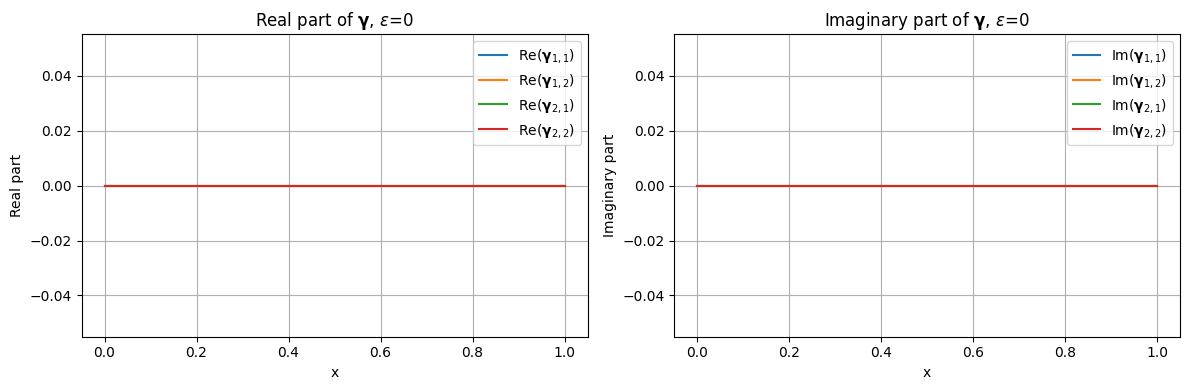

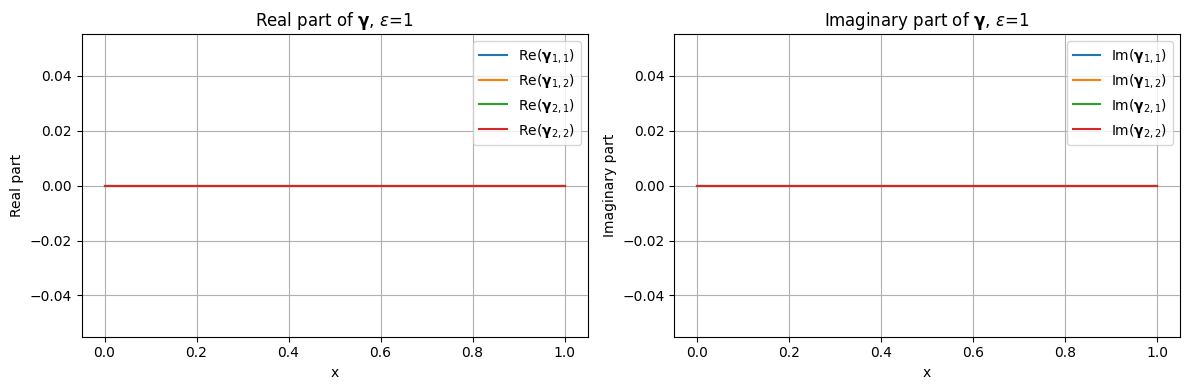

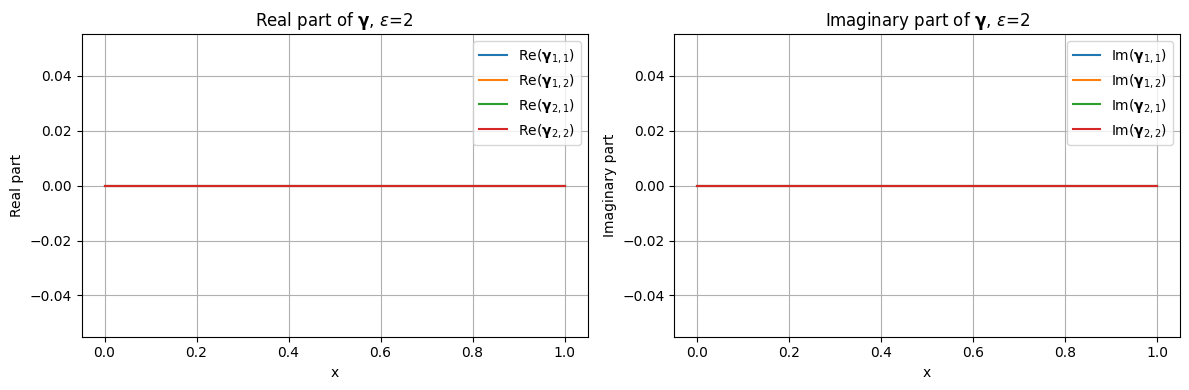

In [14]:
import functools


def plot_solutions(sol, arr: np.ndarray, epsilon: float, variable: str) -> None:
    # Plot the solution
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(sol.x, np.real(arr[:, 0, 0]), label=f"Re({variable}"+r"$_{1,1}$)")
    plt.plot(sol.x, np.real(arr[:, 0, 1]), label=f"Re({variable}"+r"$_{1,2}$)")
    plt.plot(sol.x, np.real(arr[:, 1, 0]), label=f"Re({variable}"+r"$_{2,1}$)")
    plt.plot(sol.x, np.real(arr[:, 1, 1]), label=f"Re({variable}"+r"$_{2,2}$)")
    plt.xlabel("x")
    plt.ylabel("Real part")
    plt.title(rf"Real part of {variable}, $\epsilon$={epsilon}")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(sol.x, np.imag(arr[:, 0, 0]), label=f"Im({variable}"+r"$_{1,1}$)")
    plt.plot(sol.x, np.imag(arr[:, 0, 1]), label=f"Im({variable}"+r"$_{1,2}$)")
    plt.plot(sol.x, np.imag(arr[:, 1, 0]), label=f"Im({variable}"+r"$_{2,1}$)")
    plt.plot(sol.x, np.imag(arr[:, 1, 1]), label=f"Im({variable}"+r"$_{2,2}$)")
    plt.xlabel("x")
    plt.ylabel("Imaginary part")
    plt.title(rf"Imaginary part of {variable}, $\epsilon$={epsilon}")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


x = np.linspace(0, L, 101)
y = np.zeros((32, 101))

for epsilon in (0, 1, 2):
    sol_eps = solve_bvp(functools.partial(f_oppg_2e, epsilon=epsilon), bc_oppg_2f, x, y)

    gamma_sol, gamma_tilde_sol, omega_sol, omega_tilde_sol = vec_to_matrices(
        sol_eps.sol(x).T
    )
    plot_solutions(sol_eps, gamma_sol, epsilon, r"$\mathbf{\gamma}$")


Vi forventet nullløsning ettersom det initielle gjettet var null og begge randverdiene også var lik null. Vi forventer at ulike verdier av epsilon ikke vil forandre resultatene, ettersom de uansett vil bli null. Vi ser at nullløsningen oppfyller usadel-ligningene og er dermed en gyldig løsning.

### Plots
 - Alle elementene er null, for alle epsilon og posisjoner

Resultatene vi fikk var som vi forventet.

# Oppgave 2h

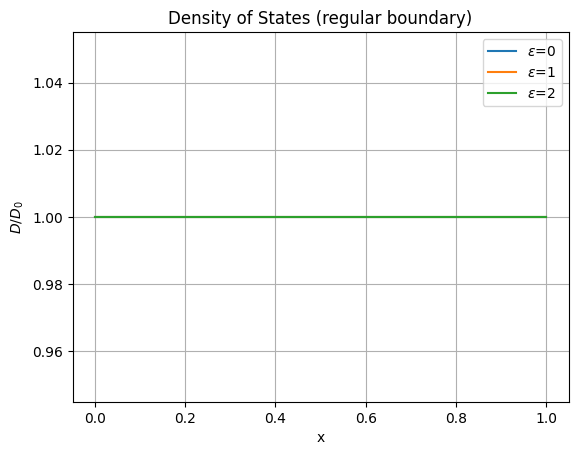

In [15]:
def green_function(gamma: np.ndarray, gamma_tilde: np.ndarray) -> np.ndarray:
    top_left = 2 * N(gamma, gamma_tilde) - IDENTITY_2X2
    top_right = 2 * N(gamma, gamma_tilde) @ gamma
    bottom_left = -2 * N_tilde(gamma, gamma_tilde) @ gamma_tilde
    bottom_right = -2 * N_tilde(gamma, gamma_tilde) + IDENTITY_2X2

    return np.block([[top_left, top_right], [bottom_left, bottom_right]])


_rho_hat_3 = np.block([[IDENTITY_2X2, ZERO_2X2], [ZERO_2X2, -IDENTITY_2X2]])


def rho_hat_3() -> np.ndarray:
    return _rho_hat_3


def state_density(gamma: np.ndarray, gamma_tilde: np.ndarray) -> np.ndarray:
    matrix_product = rho_hat_3() @ green_function(gamma, gamma_tilde)
    return np.real(np.trace(matrix_product, axis1=-1, axis2=-2)) / 4


for epsilon in (0, 1, 2):
    sol_eps = solve_bvp(functools.partial(f_oppg_2e, epsilon=epsilon), bc_oppg_2f, x, y)
    gamma_sol, gamma_tilde_sol, omega_sol, omega_tilde_sol = vec_to_matrices(
        sol_eps.sol(x).T
    )
    plt.plot(
        sol_eps.x, state_density(gamma_sol, gamma_tilde_sol), label=fr"$\epsilon$={epsilon}"
    )
plt.legend()
plt.ylabel(r"$D/D_0$")
plt.xlabel("x")
plt.title("Density of States (regular boundary)")
plt.grid()
plt.show()

### Plot
 - Som forventet er $D/D_0 = 1$, ettersom vi har kun vanlig, ikke-superledende metall, som per definisjon har $D(x, \epsilon)=D_0$. 

# Oppgave 2i

In [16]:
def bc_oppg_2i(
    v_l: np.ndarray,
    v_r: np.ndarray,
    epsilon: float,
    left_phase: float = 0,
    right_phase: float = 0,
    L: float = 1,
) -> np.ndarray:
    def v_sigma(sigma: int) -> float:
        return np.atanh(sigma / (epsilon + 1j * DELTA))

    s_p = np.sinh(v_sigma(1))
    s_n = np.sinh(v_sigma(-1))
    c_p = np.cosh(v_sigma(1))
    c_n = np.cosh(v_sigma(-1))

    ricatti_element_pos = s_p / (1 + c_p)
    ricatti_element_neg = s_n / (1 + c_n)

    ricatti_matrix = np.array([[0, ricatti_element_pos], [ricatti_element_neg, 0]])
    ricatti_tilde_matrix = np.array(
        [[0, ricatti_element_neg], [ricatti_element_pos, 0]]
    )

    # Defining boundary ricatti matrices
    gamma_bc_l = ricatti_matrix * np.exp(1j * left_phase)
    gamma_bc_r = ricatti_matrix * np.exp(1j * right_phase)
    gamma_tilde_bc_l = ricatti_tilde_matrix * np.exp(-1j * left_phase)
    gamma_tilde_bc_r = ricatti_tilde_matrix * np.exp(-1j * right_phase)

    N_l = np.linalg.inv(IDENTITY_2X2 - gamma_bc_l @ gamma_tilde_bc_l)
    N_tilde_l = np.linalg.inv(IDENTITY_2X2 - gamma_tilde_bc_l @ gamma_bc_l)
    N_r = np.linalg.inv(IDENTITY_2X2 - gamma_bc_r @ gamma_tilde_bc_r)
    N_tilde_r = np.linalg.inv(IDENTITY_2X2 - gamma_tilde_bc_r @ gamma_bc_r)

    gamma_l, gamma_tilde_l, omega_l, omega_tilde_l = vec_to_matrices(v_l)
    gamma_r, gamma_tilde_r, omega_r, omega_tilde_r = vec_to_matrices(v_r)

    # Boundary conditions
    bc_l_1 = omega_l + 1 / (L * ZETA) * (
        IDENTITY_2X2 - gamma_l @ gamma_tilde_bc_l
    ) @ N_l @ (gamma_bc_l - gamma_l)

    bc_l_2 = omega_tilde_l + 1 / (L * ZETA) * (
        IDENTITY_2X2 - gamma_tilde_l @ gamma_bc_l
    ) @ N_tilde_l @ (gamma_tilde_bc_l - gamma_tilde_l)

    bc_r_1 = omega_r - 1 / (L * ZETA) * (
        IDENTITY_2X2 - gamma_r @ gamma_tilde_bc_r
    ) @ N_r @ (gamma_bc_r - gamma_r)

    bc_r_2 = omega_tilde_r - 1 / (L * ZETA) * (
        IDENTITY_2X2 - gamma_tilde_r @ gamma_bc_r
    ) @ N_tilde_r @ (gamma_tilde_bc_r - gamma_tilde_r)

    return matrices_to_vec(bc_l_1, bc_l_2, bc_r_1, bc_r_2)

Vi nå har lagd en funksjon for randverdiene til usadelligningene som fungerer for superledende metaller på randene.

# Oppgave 2j

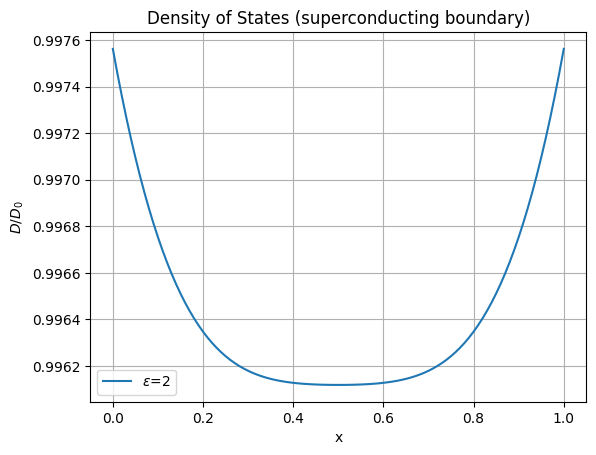

In [17]:
x = np.linspace(0, L, 101)
y = np.zeros((32, 101))
EPSILON = 2

sol_eps = solve_bvp(
    functools.partial(f_oppg_2e, epsilon=EPSILON),
    functools.partial(bc_oppg_2i, epsilon=EPSILON),
    x,
    y,
)
gamma_sol, gamma_tilde_sol, omega_sol, omega_tilde_sol = vec_to_matrices(sol_eps.sol(x).T)

plt.plot(
    x, state_density(gamma_sol, gamma_tilde_sol), label=fr"$\epsilon$={EPSILON}"
)
plt.legend()
plt.ylabel(r"$D/D_0$")
plt.xlabel("x")
plt.title("Density of States (superconducting boundary)")
plt.grid()
plt.show()

Ved $\epsilon=2$ ligger vi godt utenfor gapet i superlederen, noe som vi ser i fig.1 i oppgaveteksten. Altså oppfører superlederen seg nesten likt som et vanlig metall. Vi forventer dermed at også metallet i midten av junction oppfører seg ganske vanlig og har tilstandstettheten nær 1 for alle x. Vi ser likevel et tegn på at de superledene effektene "lekker" litt inn, hvilket vil si at vi med synkende epsilon vil bevege oss mot en tilstand der elektronene har færre og færre mulige energitilstander som betyr at de etterhvert blir tvunget til å danne cooper-par.

### Plot
 - På plottet ser vi at tilstandstettheten er ganske nær 1 for alle x. Men vi ser at den har en tydelig avhengighet av x, og har endret seg litt ned fra 1.

# Oppgave 2k

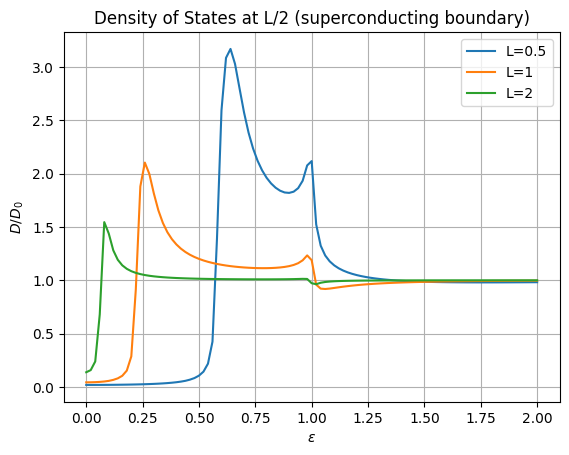

In [18]:
epsilons = np.linspace(2, 0, 101)
lengths = (0.5, 1, 2)

for length in lengths:
    x = np.linspace(0, length, 101)
    y_guess = np.zeros((32, 101))
    densities = []
    for epsilon in epsilons:
        sol_eps = solve_bvp(
            functools.partial(f_oppg_2e, epsilon=epsilon),
            functools.partial(bc_oppg_2i, epsilon=epsilon, L=length),
            x,
            y_guess,
        )
        y_guess = sol_eps.sol(x)
        gamma_sol, gamma_tilde_sol, omega_sol, omega_tilde_sol = vec_to_matrices(
            sol_eps.sol(x).T
        )
        densities.append(state_density(gamma_sol, gamma_tilde_sol)[50])

    plt.plot(epsilons, densities, label=f"L={length}")
plt.legend()
plt.ylabel(r"$D/D_0$")
plt.xlabel(r"$\epsilon$")
plt.title("Density of States at L/2 (superconducting boundary)")
plt.grid()
plt.show()

### Plot
 - Vi ser tre tydelige mini-gap grafer, som alle ligner på grafen for superleder.
 - De har alle en slags perturbasjon rundt $\epsilon=1$, som mest sannsynlig har noe med at tilstandstettheten til superlederen øker dramatisk rundt dette punktet.
 - Grafen med L=2 har minst tydelig minigap og pertubasjon rundt $\epsilon=1$. 
 - Grafen med L=1 har tydelig minigap og en liten pertubasjon rundt $\epsilon=1$. 
 - Grafen med L=1/2 har relativt stort minigap og tydelig pertubasjon rundt $\epsilon=1$. Denne har også desidert høyest toppunkt av tilstandstettheten.

Vi ser tydelig at minigapet avhenger av lengden på metallet, og et kortere metall fører til et større minigap. Den mindre lengden gjør det lettere for superlederene å "lekke" sine egenskaper gjennom hele metallet.

# Oppgave 2l

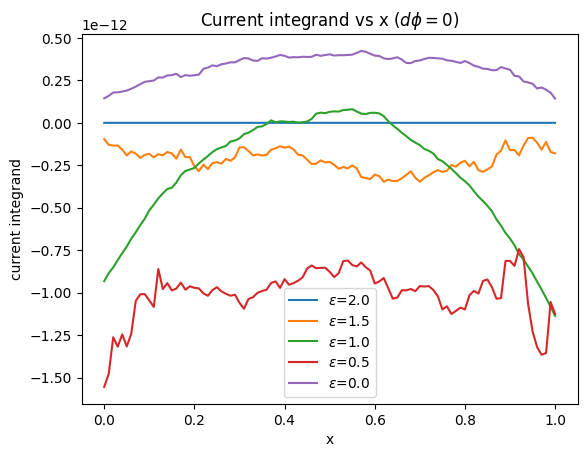

In [19]:
def N_dx(
    gamma: np.ndarray,
    gamma_tilde: np.ndarray,
    omega: np.ndarray,
    omega_tilde: np.ndarray,
) -> np.ndarray:
    _N = N(gamma, gamma_tilde)
    return _N @ (omega @ gamma_tilde + gamma @ omega_tilde) @ _N


def N_tilde_dx(
    gamma: np.ndarray,
    gamma_tilde: np.ndarray,
    omega: np.ndarray,
    omega_tilde: np.ndarray,
) -> np.ndarray:
    _N_tilde = N_tilde(gamma, gamma_tilde)
    return _N_tilde @ (omega_tilde @ gamma + gamma_tilde @ omega) @ _N_tilde


def green_function_dx(
    gamma: np.ndarray,
    gamma_tilde: np.ndarray,
    omega: np.ndarray,
    omega_tilde: np.ndarray,
) -> np.ndarray:
    _N_dx = N_dx(gamma, gamma_tilde, omega, omega_tilde)
    _N_tilde_dx = N_tilde_dx(gamma, gamma_tilde, omega, omega_tilde)
    top_left = _N_dx
    top_right = N(gamma, gamma_tilde) @ omega + _N_dx @ gamma
    bottom_left = -N_tilde(gamma, gamma_tilde) @ omega_tilde - _N_tilde_dx @ gamma_tilde
    bottom_right = -_N_tilde_dx
    return 2 * np.block([[top_left, top_right], [bottom_left, bottom_right]])


def current_integrand(
    gamma: np.ndarray,
    gamma_tilde: np.ndarray,
    omega: np.ndarray,
    omega_tilde: np.ndarray,
) -> np.ndarray:
    _green_function = green_function(gamma, gamma_tilde)
    _green_function_dx = green_function_dx(gamma, gamma_tilde, omega, omega_tilde)

    matrix_product = rho_hat_3() @ (
        _green_function @ _green_function_dx - _green_function_dx @ _green_function
    )
    return np.real(np.trace(matrix_product, axis1=-1, axis2=-2))

x = np.linspace(0, L, 101)
epsilons_wanted = np.array([2, 1.5, 1, 0.5, 0])

#Solving bvp for all epsilons in range 2-0
epsilons = np.linspace(2, 0, 101)

y_guess = np.zeros((32, 101))
for epsilon in epsilons:
    sol_eps = solve_bvp(
        functools.partial(f_oppg_2e, epsilon=epsilon),
        functools.partial(bc_oppg_2i, epsilon=epsilon),
        x,
        y_guess,
    )
    y_guess = sol_eps.sol(x)
    gamma_sol, gamma_tilde_sol, omega_sol, omega_tilde_sol = vec_to_matrices(
        sol_eps.sol(x).T
    )
    _current_integrand = current_integrand(
        gamma_sol, gamma_tilde_sol, omega_sol, omega_tilde_sol
    )

    # Only plot for the specific epsilons we want
    if (np.abs(epsilon - epsilons_wanted) < (2/202)).any():
        plt.plot(x, _current_integrand, label=fr"$\epsilon$={epsilon}")
plt.legend()
plt.ylabel("current integrand")
plt.xlabel("x")
plt.title(r"Current integrand vs x ($d\phi=0$)")
plt.show()

### Plot
 - Vi ser at integranden er numerisk lik null for alle epsilon.

# Oppgave 2m

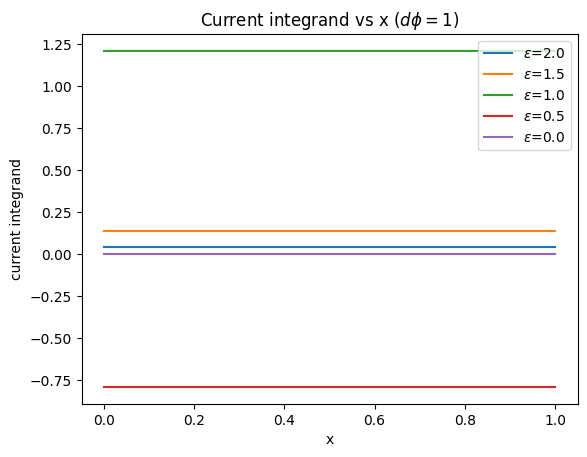

Integrand numerically constant over position? True


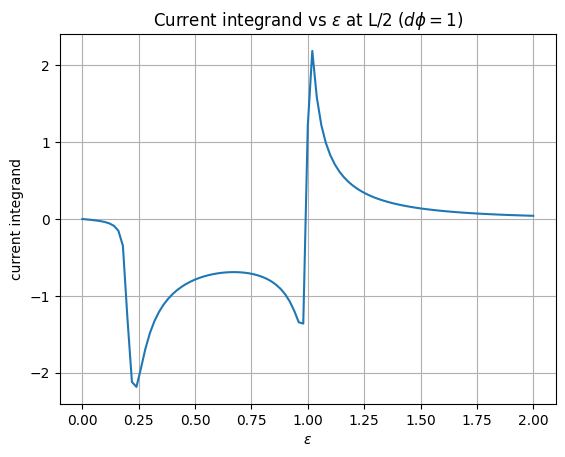

In [20]:
x = np.linspace(0, L, 101)
epsilons = np.linspace(2, 0, 101)

y_guess = np.zeros((32, 101))
current_integrands = np.zeros(shape=(101, 101))
for idx, epsilon in enumerate(epsilons):
    sol_eps = solve_bvp(
        functools.partial(f_oppg_2e, epsilon=epsilon),
        functools.partial(bc_oppg_2i, epsilon=epsilon, left_phase=1),
        x,
        y_guess,
    )
    y_guess = sol_eps.sol(x)
    ricatti_matrixes = vec_to_matrices(sol_eps.sol(x).T)
    _current_integrand = current_integrand(*ricatti_matrixes)
    current_integrands[idx] = _current_integrand

    if (np.abs(epsilon - epsilons_wanted) < (2/202)).any():
        plt.plot(x, _current_integrand, label=fr"$\epsilon$={epsilon}")

plt.legend()
plt.ylabel("current integrand")
plt.xlabel("x")
plt.title(r"Current integrand vs x ($d\phi=1$)")
plt.show()

print(
    "Integrand numerically constant over position?",
    np.isclose(
        current_integrands, current_integrands[:, [0]], atol=1e-5, rtol=1e-3
    ).all(),
)

plt.plot(epsilons, current_integrands[:, 50])
plt.ylabel("current integrand")
plt.xlabel(r"$\epsilon$")
plt.title(r"Current integrand vs $\epsilon$ at L/2 ($d\phi=1$)")
plt.grid()
plt.show()

### Plot 1
 - Vi observerer at integranden er numerisk konstant som funksjon av x og har ulike verdier for ulike epsilon. Dette er tydelig forskjellig fra oppgave 2l ettersom alle verdiene ikke er numerisk lik 0. Dette kommer av at vi nå har en faseforskjell.

### Plot 2
 - For $\epsilon<1$ ser det ut til at strømmingen er negativ, og positiv for $\epsilon>1$.
 - Sterk endring rundt $\epsilon=1$, der vi er på kanten av det superledende gapet for superlederene.

 Lave energier bidrar til en strøm som går i motsatt retning av det de høye energiene bidrar til. Den totale Josephson-strømmen er nettostrømmen fra disse konkurerende bidragene fra ulike energier.

# Oppgave 2n

In [21]:
import scipy.integrate as spi


phase_diffs = np.linspace(0, 2 * np.pi, 20)
x = np.linspace(0, L, 101)
epsilons = np.linspace(2, 0, 101)
currents = []

for phase_diff in phase_diffs:
    y_guess = np.zeros((32, 101))
    current_integrands = np.zeros(shape=(101, 101))
    for idx, epsilon in enumerate(epsilons):
        sol_eps = solve_bvp(
            functools.partial(f_oppg_2e, epsilon=epsilon),
            functools.partial(bc_oppg_2i, epsilon=epsilon, left_phase=phase_diff),
            x,
            y_guess,
        )
        y_guess = sol_eps.sol(x)
        gamma_sol, gamma_tilde_sol, omega_sol, omega_tilde_sol = vec_to_matrices(
            sol_eps.sol(x).T
        )
        _current_integrand = current_integrand(
            gamma_sol, gamma_tilde_sol, omega_sol, omega_tilde_sol
        )
        current_integrands[idx] = _current_integrand
    current = spi.simpson(current_integrands[:, 50], epsilons)
    currents.append(current)

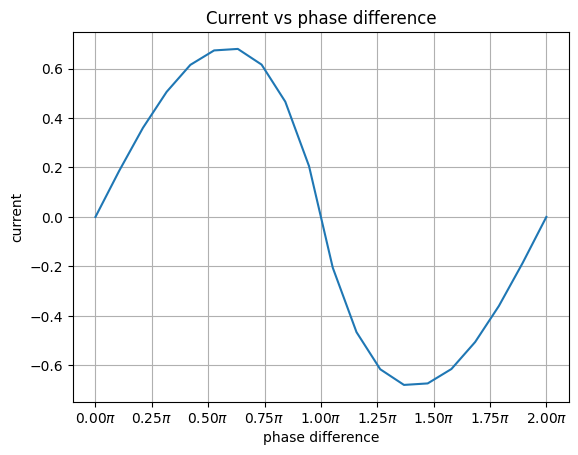

In [22]:
plt.plot(phase_diffs, currents)
plt.ylabel("current")
plt.xlabel("phase difference")
plt.title("Current vs phase difference")
plt.xticks(x_ticks_2_pi, x_ticks_2_pi_labels)
plt.grid()
plt.show()

### Plot
 - Vi ser at den totale strømmen avhenger sinusoidalt av faseforskjellen.
 - Den er litt "sammenpresset", slik at ekstremalpunktene ikke treffer perfekt på $\pi/2$ og $3\pi/2$

Plottet illustrerer tydelig grunnen til at koherenseffekter beskrives som interferens mellom ulike kvantemekaniske faser, ettersom vi ser at hvis de superledende materialene har egenskaper som er i motfase så kansellerer de hverandre. Grunnen til at det ikke er en konstruktiv interferens ved phi lik 0 og 2*pi er at når det ikke er noen faseforskjell så er det heller ingen asymmetri eller foretrukken retning for strømmen å bevege seg i.

![alt text](<tinywow_tinywow_NO_KI - deklareringsskjema per vår 2024_89241537_89241574_1.jpg>)